<a href="https://colab.research.google.com/github/anaam03/Projects/blob/main/Copy_of_SIH_TRAINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of the dataset:
           Date & Time Train Type  Temperature (°C)  Rainfall (mm)  \
0  2023-01-13 19:36:00      Local                10          30.55   
1  2023-04-16 21:52:00      Local                17          27.05   
2  2023-04-08 17:58:00    Freight                -4          41.62   
3  2023-01-13 11:28:00    Express                 2          27.49   
4  2023-01-05 09:52:00    Freight                27          14.84   

   Wind Speed (km/h)  Visibility (km)  Delay (minutes)  
0              24.79             4.11               42  
1              94.10             1.03               59  
2              16.49             0.32               28  
3              70.21             9.41               51  
4               5.42             1.80               25  

Column names:
Index(['Date & Time', 'Train Type', 'Temperature (°C)', 'Rainfall (mm)',
       'Wind Speed (km/h)', 'Visibility (km)', 'Delay (minutes)'],
      dtype='object')

Model Evaluation:
Mean Squared

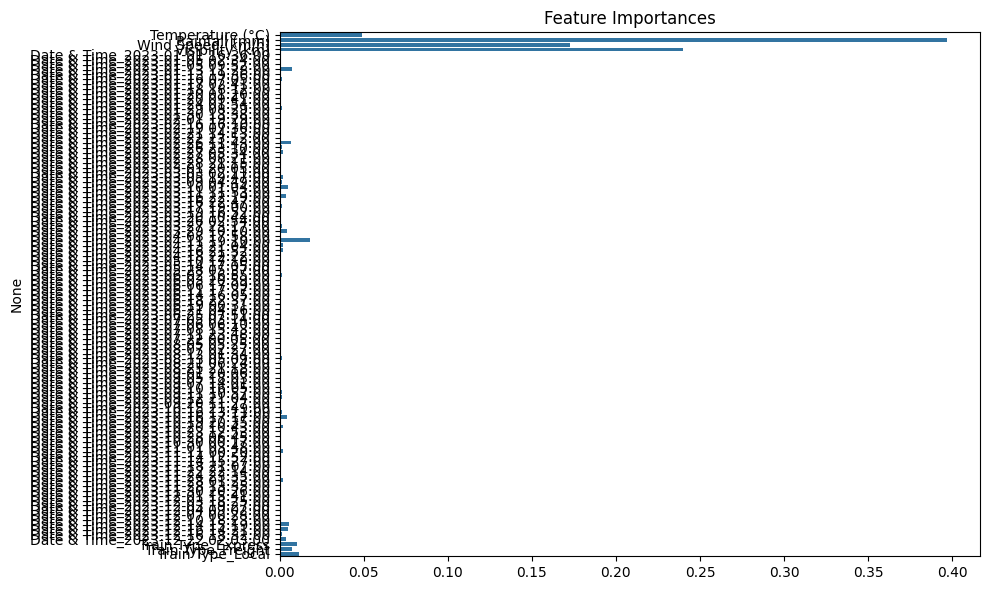


Predicted Delay (minutes): 27.17


In [ ]:
# Step 1: Install dependencies (if needed)
!pip install pandas scikit-learn matplotlib seaborn --quiet

# Step 2: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 3: Load the dataset
file_path = '/content/train_weather_delay_dataset.csv'  # Update if needed
df = pd.read_csv(file_path)

# Step 4: Explore dataset
print("First 5 rows of the dataset:")
print(df.head())

print("\nColumn names:")
print(df.columns)

# Step 5: Handle missing values (drop or fill)
df = df.dropna()

# Step 6: Define features (X) and target (y)
# Assuming 'delay_minutes' is the target column, adjust if your target column name is different
target_column = 'Delay (minutes)' # Corrected column name
X = df.drop(columns=[target_column])
y = df[target_column]

# Step 7: Convert categorical variables if any
X = pd.get_dummies(X)

# Step 8: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 9: Train model (Random Forest Regressor)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 10: Evaluate the model
y_pred = model.predict(X_test)

print("\nModel Evaluation:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Step 11: Feature importance plot
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

# Step 12: Prediction example
# You can change the values here to simulate input
sample_input = X.iloc[[0]]  # Take the first row as an example
predicted_delay = model.predict(sample_input)
print("\nPredicted Delay (minutes):", predicted_delay[0])

In [ ]:
# Step A: Create real test input based on your dataset's structure
# Example values – change these based on your understanding
test_input = pd.DataFrame([{
    'Temperature (°C)': 28,
    'Rainfall (mm)': 10,
    'Wind Speed (km/h)': 18,
    'Visibility (km)': 1.8,
    'Train Type_Express': 1,
    'Train Type_Local': 0,
    'Train Type_Freight': 0
}])

# Make sure all expected columns are present
for col in X.columns:
    if col not in test_input.columns:
        test_input[col] = 0

test_input = test_input[X.columns]  # Match the order
predicted = model.predict(test_input)
print("Predicted Train Delay:", round(predicted[0], 2), "minutes")

Predicted Train Delay: 26.53 minutes


/tmp/ipython-input-2748621029.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_input[col] = 0
/tmp/ipython-input-2748621029.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_input[col] = 0
